<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Pr%C3%A1ctica_20_Ejercicios_con_EDA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 20 Ejercicios con EDA 1



---



Alumno: Carlos Iván Ramírez Martínez <br>
Matricula: 260499 <br>
Email: al260499@alumnos.uacj.mx <br>


---


## Objetivo:
Utiliza el conjunto de datos "Air Quality" disponible al final de esta practica. Este conjunto contiene datos horarios de sensores de calidad del aire, incluyendo niveles de CO, NOx, y otros contaminantes. El conjunto de datos tiene valores faltantes y columnas categóricas (por ejemplo, el día de la semana).

## Instrucciones para los estudiantes:

1. Descargar el archivo AirQuality.csv desde el enlace proporcionado.
2. Realizar un EDA completo, incluyendo:
    * Descripción de los datos (medias, medianas, desviaciones estándar, etc.).
    * Histogramas para las columnas numéricas.
    * De la columna Time obten el día de la Semana y realiza una gráfica de barras.
    * Boxplots para identificar outliers en las columnas numéricas.
    * Matriz de correlación y mapa de calor.
    * Pairplot para visualizar relaciones entre variables numéricas.
    * Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.
3. Identificar y tratar los datos faltantes utilizando técnicas como imputación por media, mediana o moda, o eliminación de filas/columnas según sea apropiado.
4. Repetir el EDA después del tratamiento de datos faltantes y comparar los resultados.

5. **Responde a estas preguntas y sube tus conclusiones a un PDF (se verificará el uso de IA).**

# Conjunto de datos

In [275]:
from google.colab import drive
drive.mount('/content/mydrive/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Drive already mounted at /content/mydrive/; to attempt to forcibly remount, call drive.mount("/content/mydrive/", force_remount=True).


In [276]:
!wget -P /content/drive/MyDrive/ClassFiles/ https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/AirQuality.csv

--2025-10-07 05:42:52--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/AirQuality.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 785065 (767K) [text/plain]
Saving to: ‘/content/drive/MyDrive/ClassFiles/AirQuality.csv.20’

AirQuality.csv.20   100%[===================>] 766.67K  --.-KB/s    in 0.05s   

2025-10-07 05:42:52 (16.5 MB/s) - ‘/content/drive/MyDrive/ClassFiles/AirQuality.csv.20’ saved [785065/785065]



### Leer datos

In [277]:
path = '/content/drive/MyDrive/ClassFiles/AirQuality.csv'
df = pd.read_csv(path, sep=';')
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


### Conocer tipos de datos en el dataset

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
dtypes: float64(8), object(7)
memory usage: 1.1+ MB


In [279]:
df['CO(GT)'] = df['CO(GT)'].str.replace(",", '.')
df['CO(GT)'] = pd.to_numeric(df['CO(GT)'], errors='coerce')
df['C6H6(GT)'] = df['C6H6(GT)'].str.replace(",", '.')
df['C6H6(GT)'] = pd.to_numeric(df['C6H6(GT)'], errors='coerce')
df['T'] = df['T'].str.replace(",", '.')
df['T'] = pd.to_numeric(df['T'], errors='coerce')
df['RH'] = df['RH'].str.replace(",", '.')
df['RH'] = pd.to_numeric(df['RH'], errors='coerce')
df['AH'] = df['AH'].str.replace(",", '.')
df['AH'] = pd.to_numeric(df['AH'], errors='coerce')

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [280]:
# Después de cambiar el signo ',' por punto y convertir las columnas a float
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [281]:

df. describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [282]:
# Tenemos un dataframe con 9471 renglones
# print(df.shape)
# y los últimos 114 rows parecieran ser los NaN
# print(df.tail(115))
# sí, usamos 9357 para crear un df que nos permita contar el número de NaNs en esta sección podremos filtrarlos.
df_null_data = df.iloc[9357:]
# Efectivamente, los últimos 114 renglones son NaN
df_null_data.isnull().sum()
df = df.dropna(how='all')
df.tail(115)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9242,30/03/2005,20.00.00,3.5,1278.0,-200.0,14.9,1147.0,438.0,505.0,185.0,1536.0,1890.0,18.2,52.6,1.0911
9243,30/03/2005,21.00.00,2.0,1130.0,-200.0,8.8,933.0,254.0,608.0,147.0,1373.0,1389.0,16.8,58.2,1.1022
9244,30/03/2005,22.00.00,1.4,1066.0,-200.0,5.8,802.0,172.0,689.0,117.0,1282.0,1090.0,16.0,61.9,1.1150
9245,30/03/2005,23.00.00,1.5,1090.0,-200.0,6.6,841.0,174.0,661.0,112.0,1317.0,1092.0,15.3,65.4,1.1260
9246,31/03/2005,00.00.00,1.2,1013.0,-200.0,4.8,754.0,146.0,729.0,101.0,1245.0,954.0,14.5,67.8,1.1171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [283]:
# Removimos efectivamente todos los NaNs
df.isna().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


# 1. Análisis Exploratorio de Datos (EDA):
  * ¿Qué patrones o tendencias observaste en los histogramas y gráficas de densidad (PDF)? ¿Alguna variable parece seguir una distribución normal?
    * *Date y Time, son columnas distribución uniforme, lo cual parece normal para datos temporales como estos.*
    * *Columnas que creo tienen distribución normal y tienen outliers: ['NMHC(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH'].*

  * ¿Qué información útil obtuviste de la gráfica de barras para el día de la semana?
    * *Los días tienen una distribución uniforme, al igual que la columna tiempo*
  *  ¿Identificaste outliers en los boxplots? ¿Cómo podrían afectar estos outliers al modelo de regresión lineal?
    * *Sí encontré outliers, para un modelo de regresión, estos valores mucho más grandes pueden sesgar la estimación de la linea predicha para los valores.*


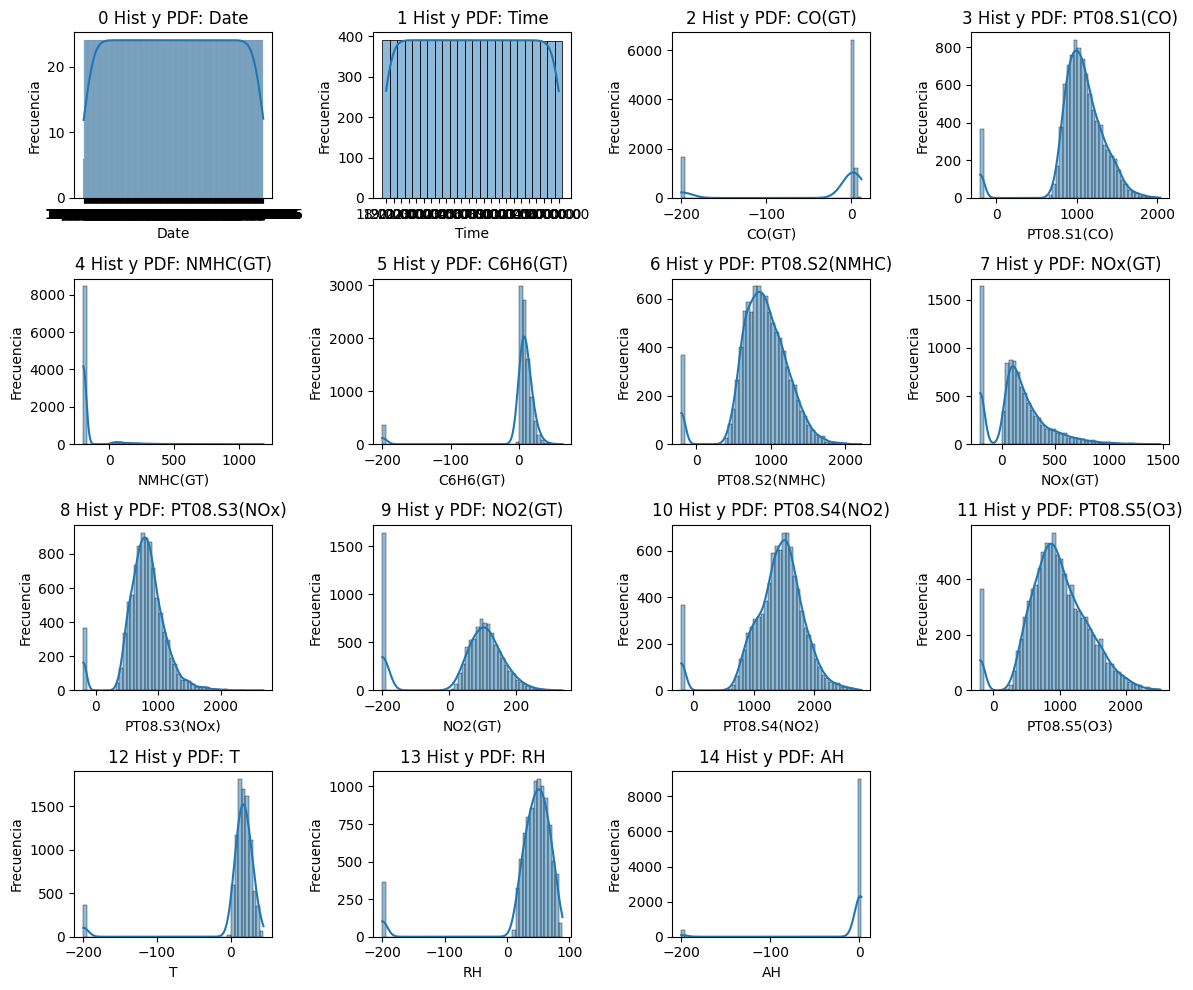

In [284]:
# Crear los gráficos de PDF e Histograma
plt.figure(figsize=(12, 10))
cols = list(df.columns)
for i, col in enumerate(cols, 1):
    plt.subplot(4, 4, i)  # Ajustar la cantidad de subgráficos según el número de columnas
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'{i-1} Hist y PDF: {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [285]:
idx = [3, 5, 6, 7, 8, 9, 10, 11, 12, 13]
list_normal = []
for i in idx:
  list_normal.append(cols[i])
print(f"Columnas que creo tienen distribución normal pero tienen outliers: \n{list_normal}")

Columnas que creo tienen distribución normal pero tienen outliers: 
['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH']


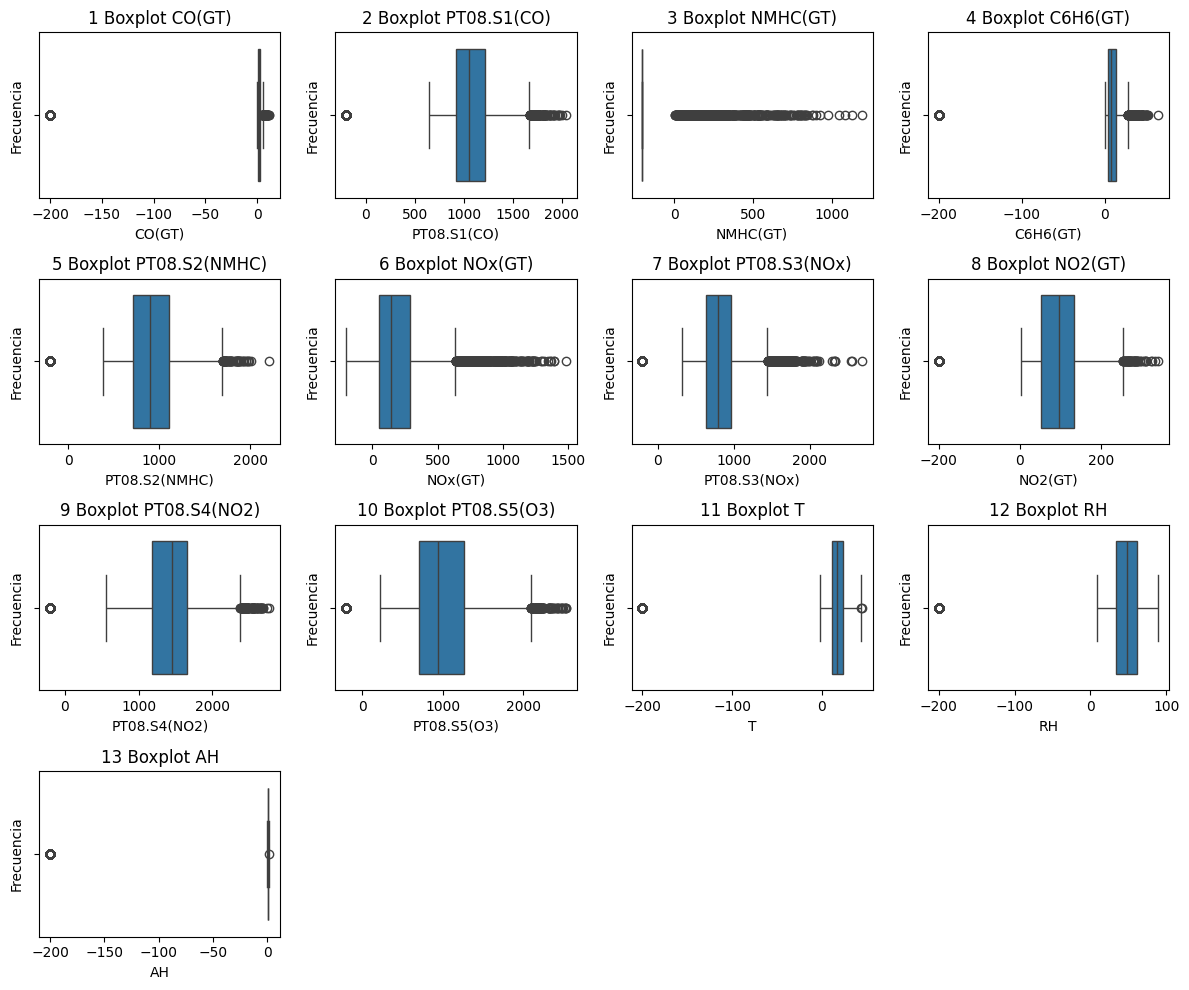

In [286]:
# Crear los gráficos de Cajas (no Date ni Time, ya que son Distribuidas uniformes)
plt.figure(figsize=(12, 10))
cols = list(df.columns[2:])
for i, col in enumerate(cols, 1):
    plt.subplot(4, 4, i)  # Ajustar la cantidad de subgráficos según el número de columnas
    sns.boxplot(df[col], orient='h')
    plt.title(f'{i} Boxplot {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 2. Pruebas de Normalidad:

  * ¿Qué conclusiones obtuviste de las pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov)? ¿Qué variables no siguen una distribución normal?
    * *Ninguna de las columnas que se les aplicó las pruebas de normalidad, las variables no siguen una distribución normal.*
  * ¿Cómo interpretas los QQplots? ¿Qué variables se desvían significativamente de la normalidad?
    * *Los outliers, afectan a las variables que habia seleccionado anteriormente como posibles distribuciones normales: 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH'.*

CO(GT)


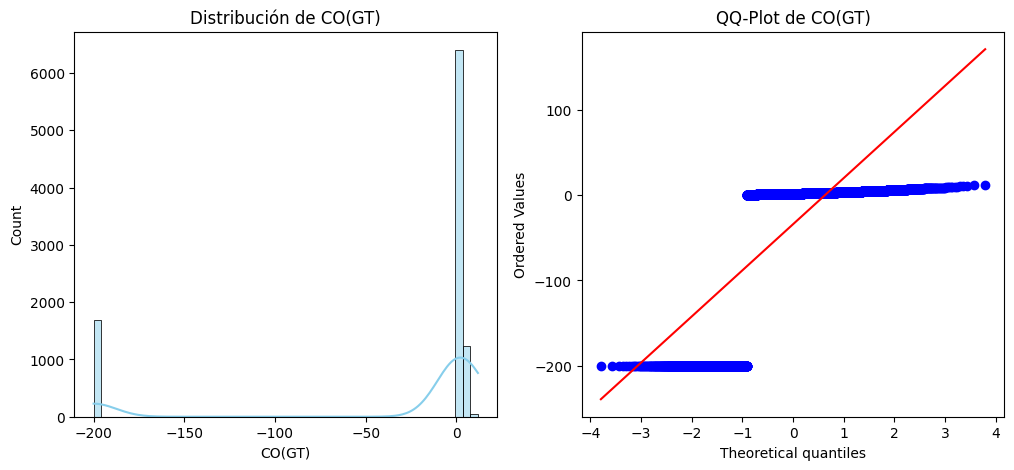


Pruebas de normalidad para la columna: CO(GT)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 2501.15334
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
PT08.S1(CO)


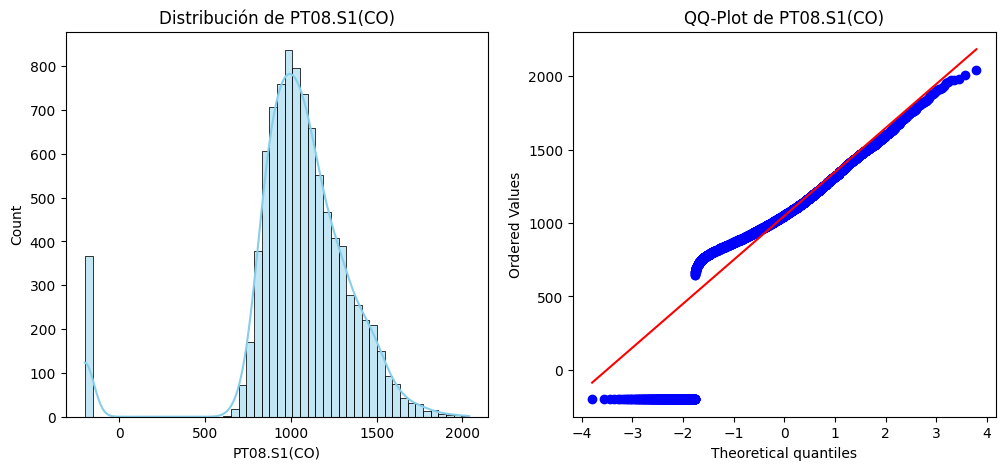


Pruebas de normalidad para la columna: PT08.S1(CO)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 355.41246
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
NMHC(GT)


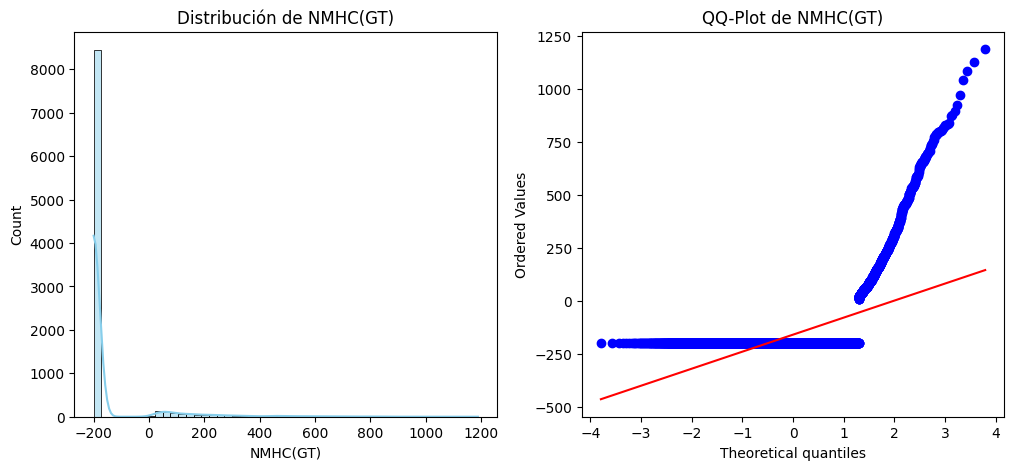


Pruebas de normalidad para la columna: NMHC(GT)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 2820.94917
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
C6H6(GT)


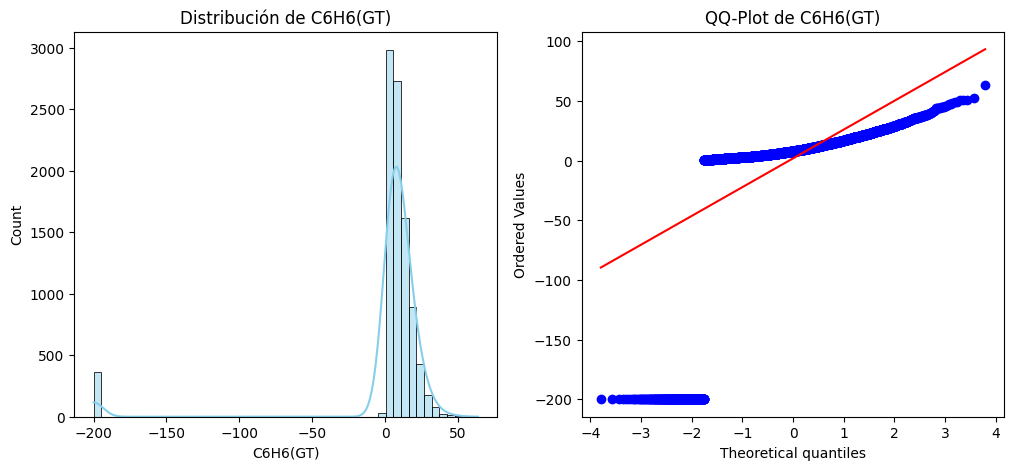


Pruebas de normalidad para la columna: C6H6(GT)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 2272.58484
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
PT08.S2(NMHC)


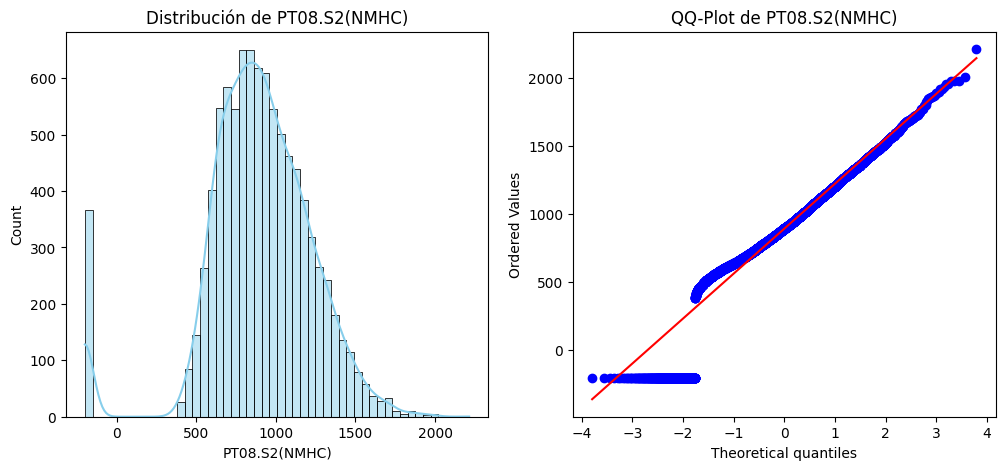


Pruebas de normalidad para la columna: PT08.S2(NMHC)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 119.20819
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
NOx(GT)


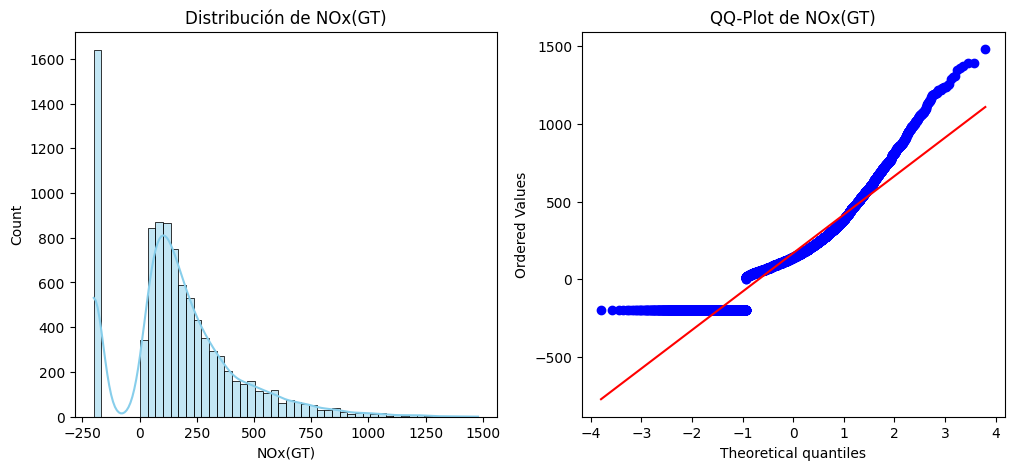


Pruebas de normalidad para la columna: NOx(GT)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 188.79429
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
PT08.S3(NOx)


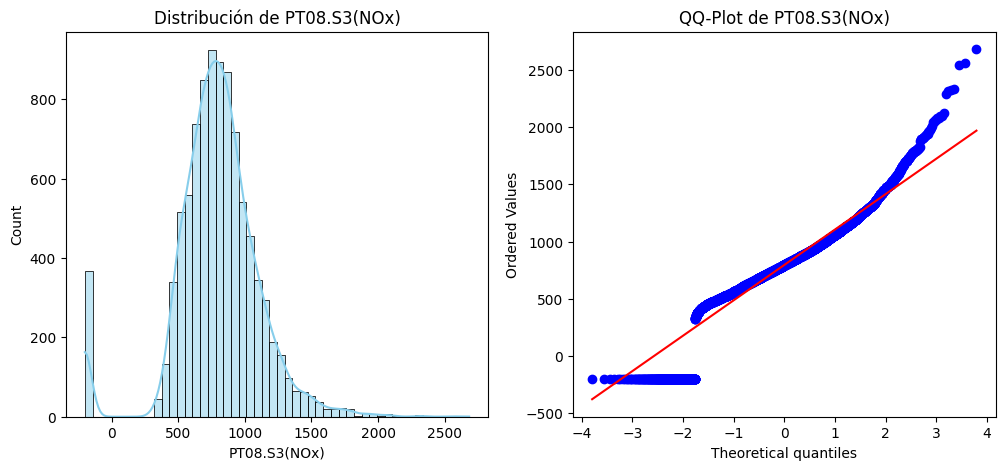


Pruebas de normalidad para la columna: PT08.S3(NOx)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 159.03112
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
NO2(GT)


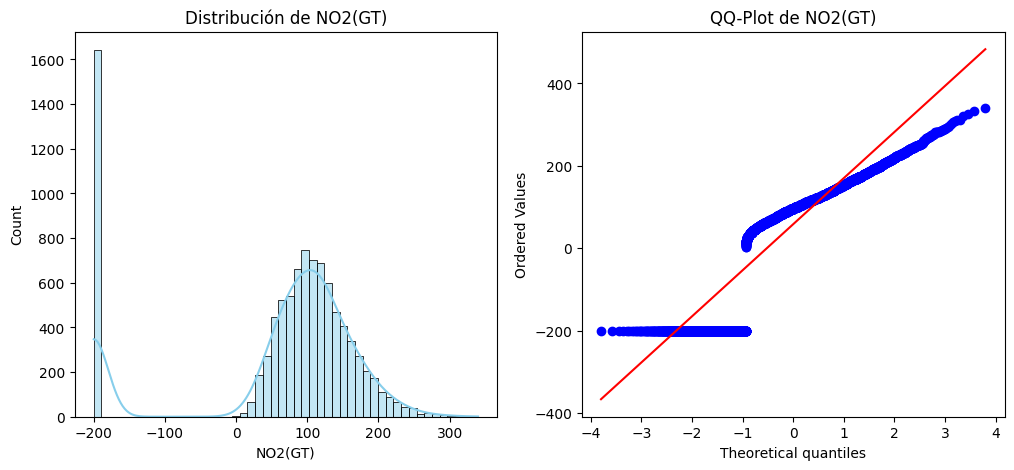


Pruebas de normalidad para la columna: NO2(GT)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 894.66163
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
PT08.S4(NO2)


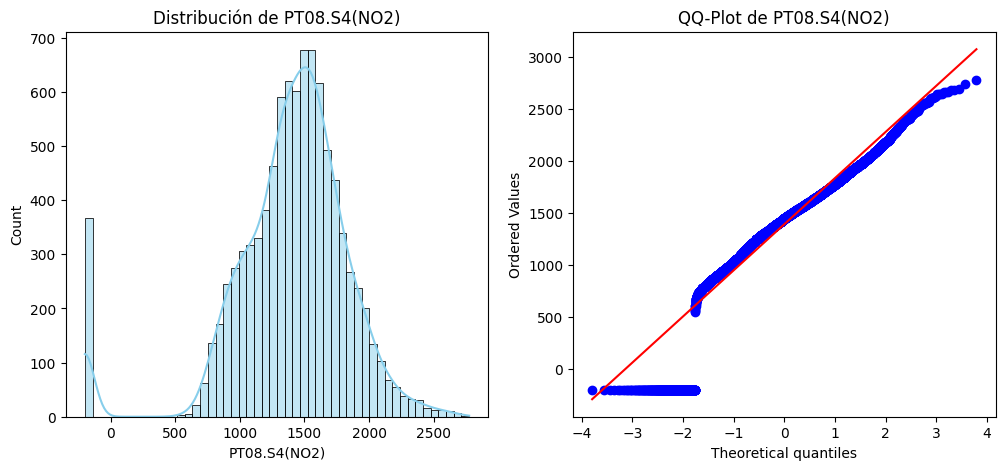


Pruebas de normalidad para la columna: PT08.S4(NO2)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 183.34158
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
PT08.S5(O3)


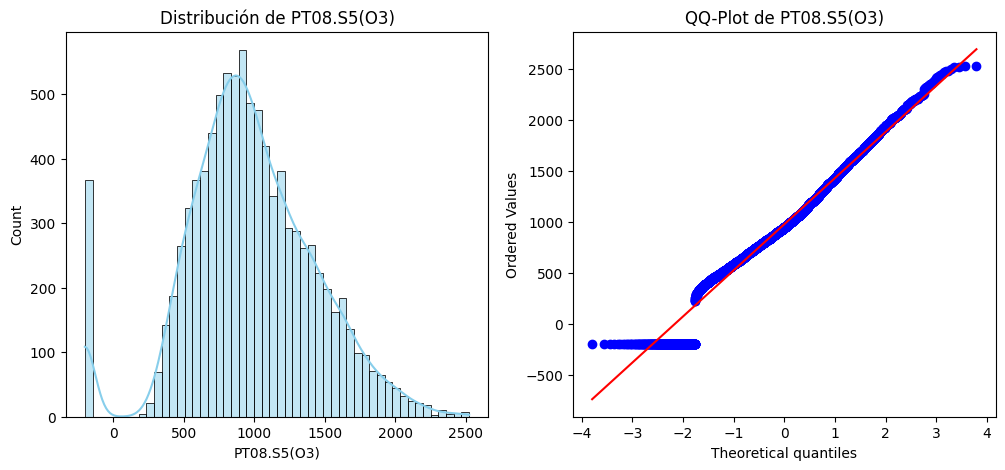


Pruebas de normalidad para la columna: PT08.S5(O3)
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 45.68234
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
T


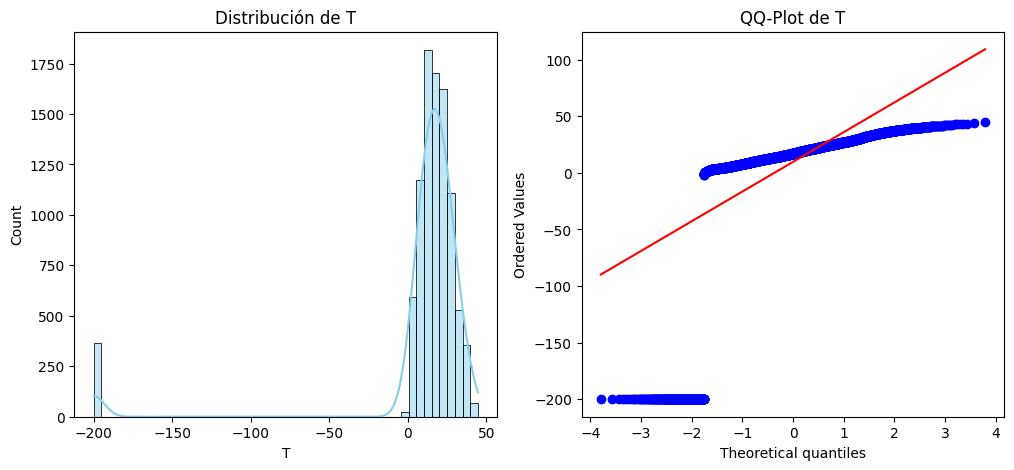


Pruebas de normalidad para la columna: T
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 2041.45858
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
RH


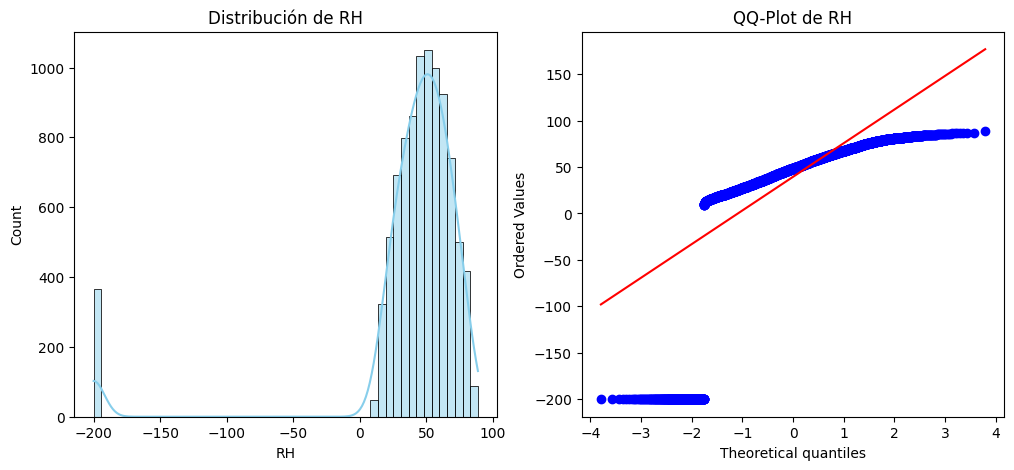


Pruebas de normalidad para la columna: RH
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 1329.04460
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000
AH


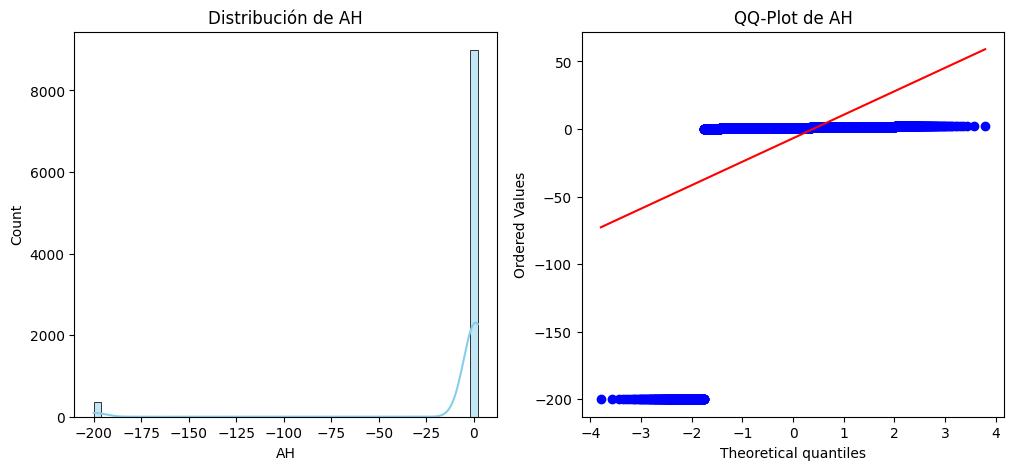


Pruebas de normalidad para la columna: AH
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 3357.68062
  Al nivel de significancia 15.0%, los datos NO parecen normales.
  Al nivel de significancia 10.0%, los datos NO parecen normales.
  Al nivel de significancia 5.0%, los datos NO parecen normales.
  Al nivel de significancia 2.5%, los datos NO parecen normales.
  Al nivel de significancia 1.0%, los datos NO parecen normales.
D'Agostino-Pearson Test: p-valor = 0.00000


In [287]:
# Función para realizar pruebas de normalidad
def normality_tests(data, column_name):
    print(f"\nPruebas de normalidad para la columna: {column_name}")

    # Prueba de Shapiro-Wilk
    shapiro_test = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))  # Muestra de 5000 para evitar problemas de cómputo
    print(f"Shapiro-Wilk Test: p-valor = {shapiro_test.pvalue:.5f}")

    # Prueba de Kolmogorov-Smirnov
    ks_test = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f"Kolmogorov-Smirnov Test: p-valor = {ks_test.pvalue:.5f}")

    # Prueba de Anderson-Darling
    anderson_test = stats.anderson(data, dist='norm')
    print(f"Anderson-Darling Test: Estadístico = {anderson_test.statistic:.5f}")
    for i in range(len(anderson_test.critical_values)):
        sl, cv = anderson_test.significance_level[i], anderson_test.critical_values[i]
        if anderson_test.statistic < cv:
            print(f"  Al nivel de significancia {sl}%, los datos parecen normales.")
        else:
            print(f"  Al nivel de significancia {sl}%, los datos NO parecen normales.")

    # Prueba de D'Agostino-Pearson
    dagostino_test = stats.normaltest(data)
    print(f"D'Agostino-Pearson Test: p-valor = {dagostino_test.pvalue:.5f}")

# Función para graficar histograma y QQ-Plot
def plot_distribution(data, column_name):
    plt.figure(figsize=(12, 5))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data, bins=50, kde=True, color="skyblue")
    plt.title(f"Distribución de {column_name}")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"QQ-Plot de {column_name}")

    plt.show()

# Aplicar pruebas de normalidad y gráficos a cada columna numérica
for column in df.columns[2:]:
  print(column)
  data = df[column]
  plot_distribution(data, column)
  normality_tests(data, column)



# 3. Tratamiento de Datos Faltantes:

  * ¿Qué estrategia utilizaste para manejar los datos faltantes? ¿Por qué elegiste esa estrategia?
    * *Utilice .dropna(how='all') en el dataframe completo.*
    * *Los valores faltantes, se reunían al final del dataframe, y todos los valores en estos 114 renglones eran todos faltantes, entonces removí los rows que cumpliran la condición de estar todos vacíos.

  * ¿Cómo cambió el EDA después de la imputación de datos? ¿Observaste diferencias significativas en las distribuciones de las variables?
    * *No observé cambios en las distribuciones, ya que todos los valores faltantes estaban incluidos como renglones completos y solo hice dropna(how='all').*

# 4. Matriz de Correlación y Pairplot:

  * ¿Qué relaciones lineales identificaste en la matriz de correlación y el pairplot?
    * Estas variables tienen correlación fuerte con la variable objetivo
      'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2) ', 'PT08.S5(O3)', 'T', 'RH'.
    * Del pairplot, se puede razonar tambien que las otras variables tienen otro tipo de relaciones no solo lineales sino polinomicas, tal ves de estas podríamos hacer feature engineering para mejorar la predicció de la variable objetivo.
  * ¿Alguna variable tiene una correlación fuerte con la variable objetivo?
    * 'C6H6(GT)', 'T', 'RH' con correlaciones superiores al 0.90.
  * ¿Cómo podrías utilizar esta información para seleccionar características (features) en un modelo de regresión lineal? Podríamos realizar combinaciones entre los otros features que nos ayuden a mejorar las predicciones que haga nuestro modelo, solo que también sería buena idea analizar si no estamos creando multicolinearidad.

In [288]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

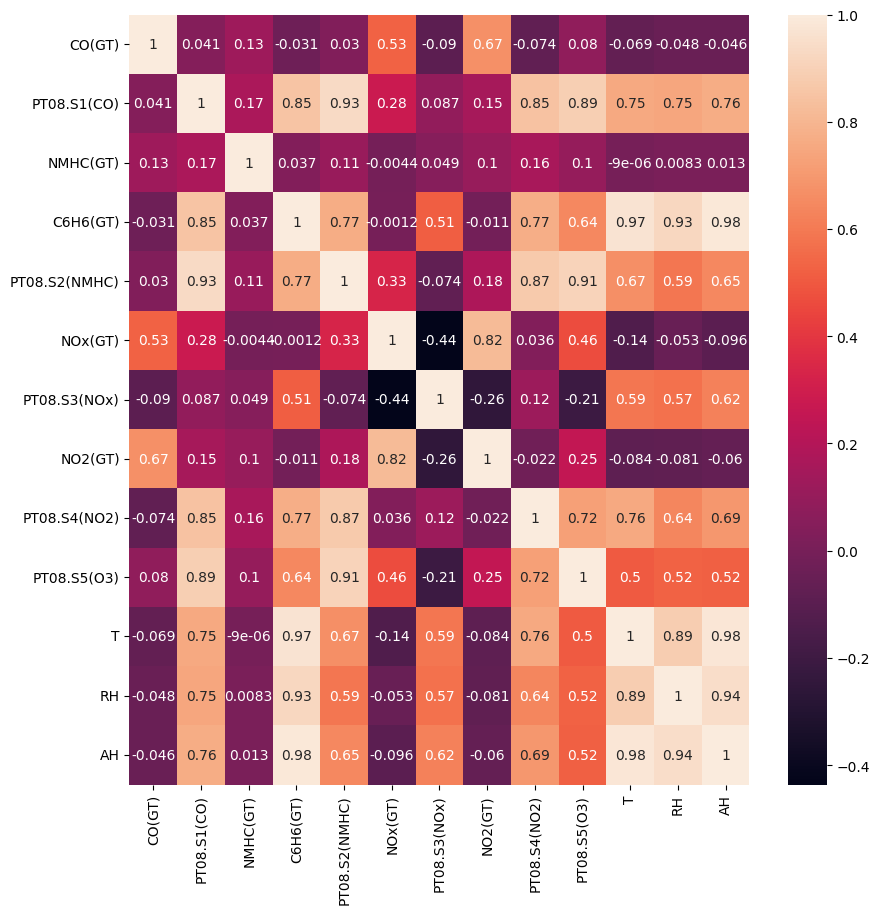

In [292]:
df_corr = df[['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
             'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
             'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
df_corr
plt.figure(figsize=(10, 10))
sns.heatmap(df_corr.corr(), annot=True)
plt.show()

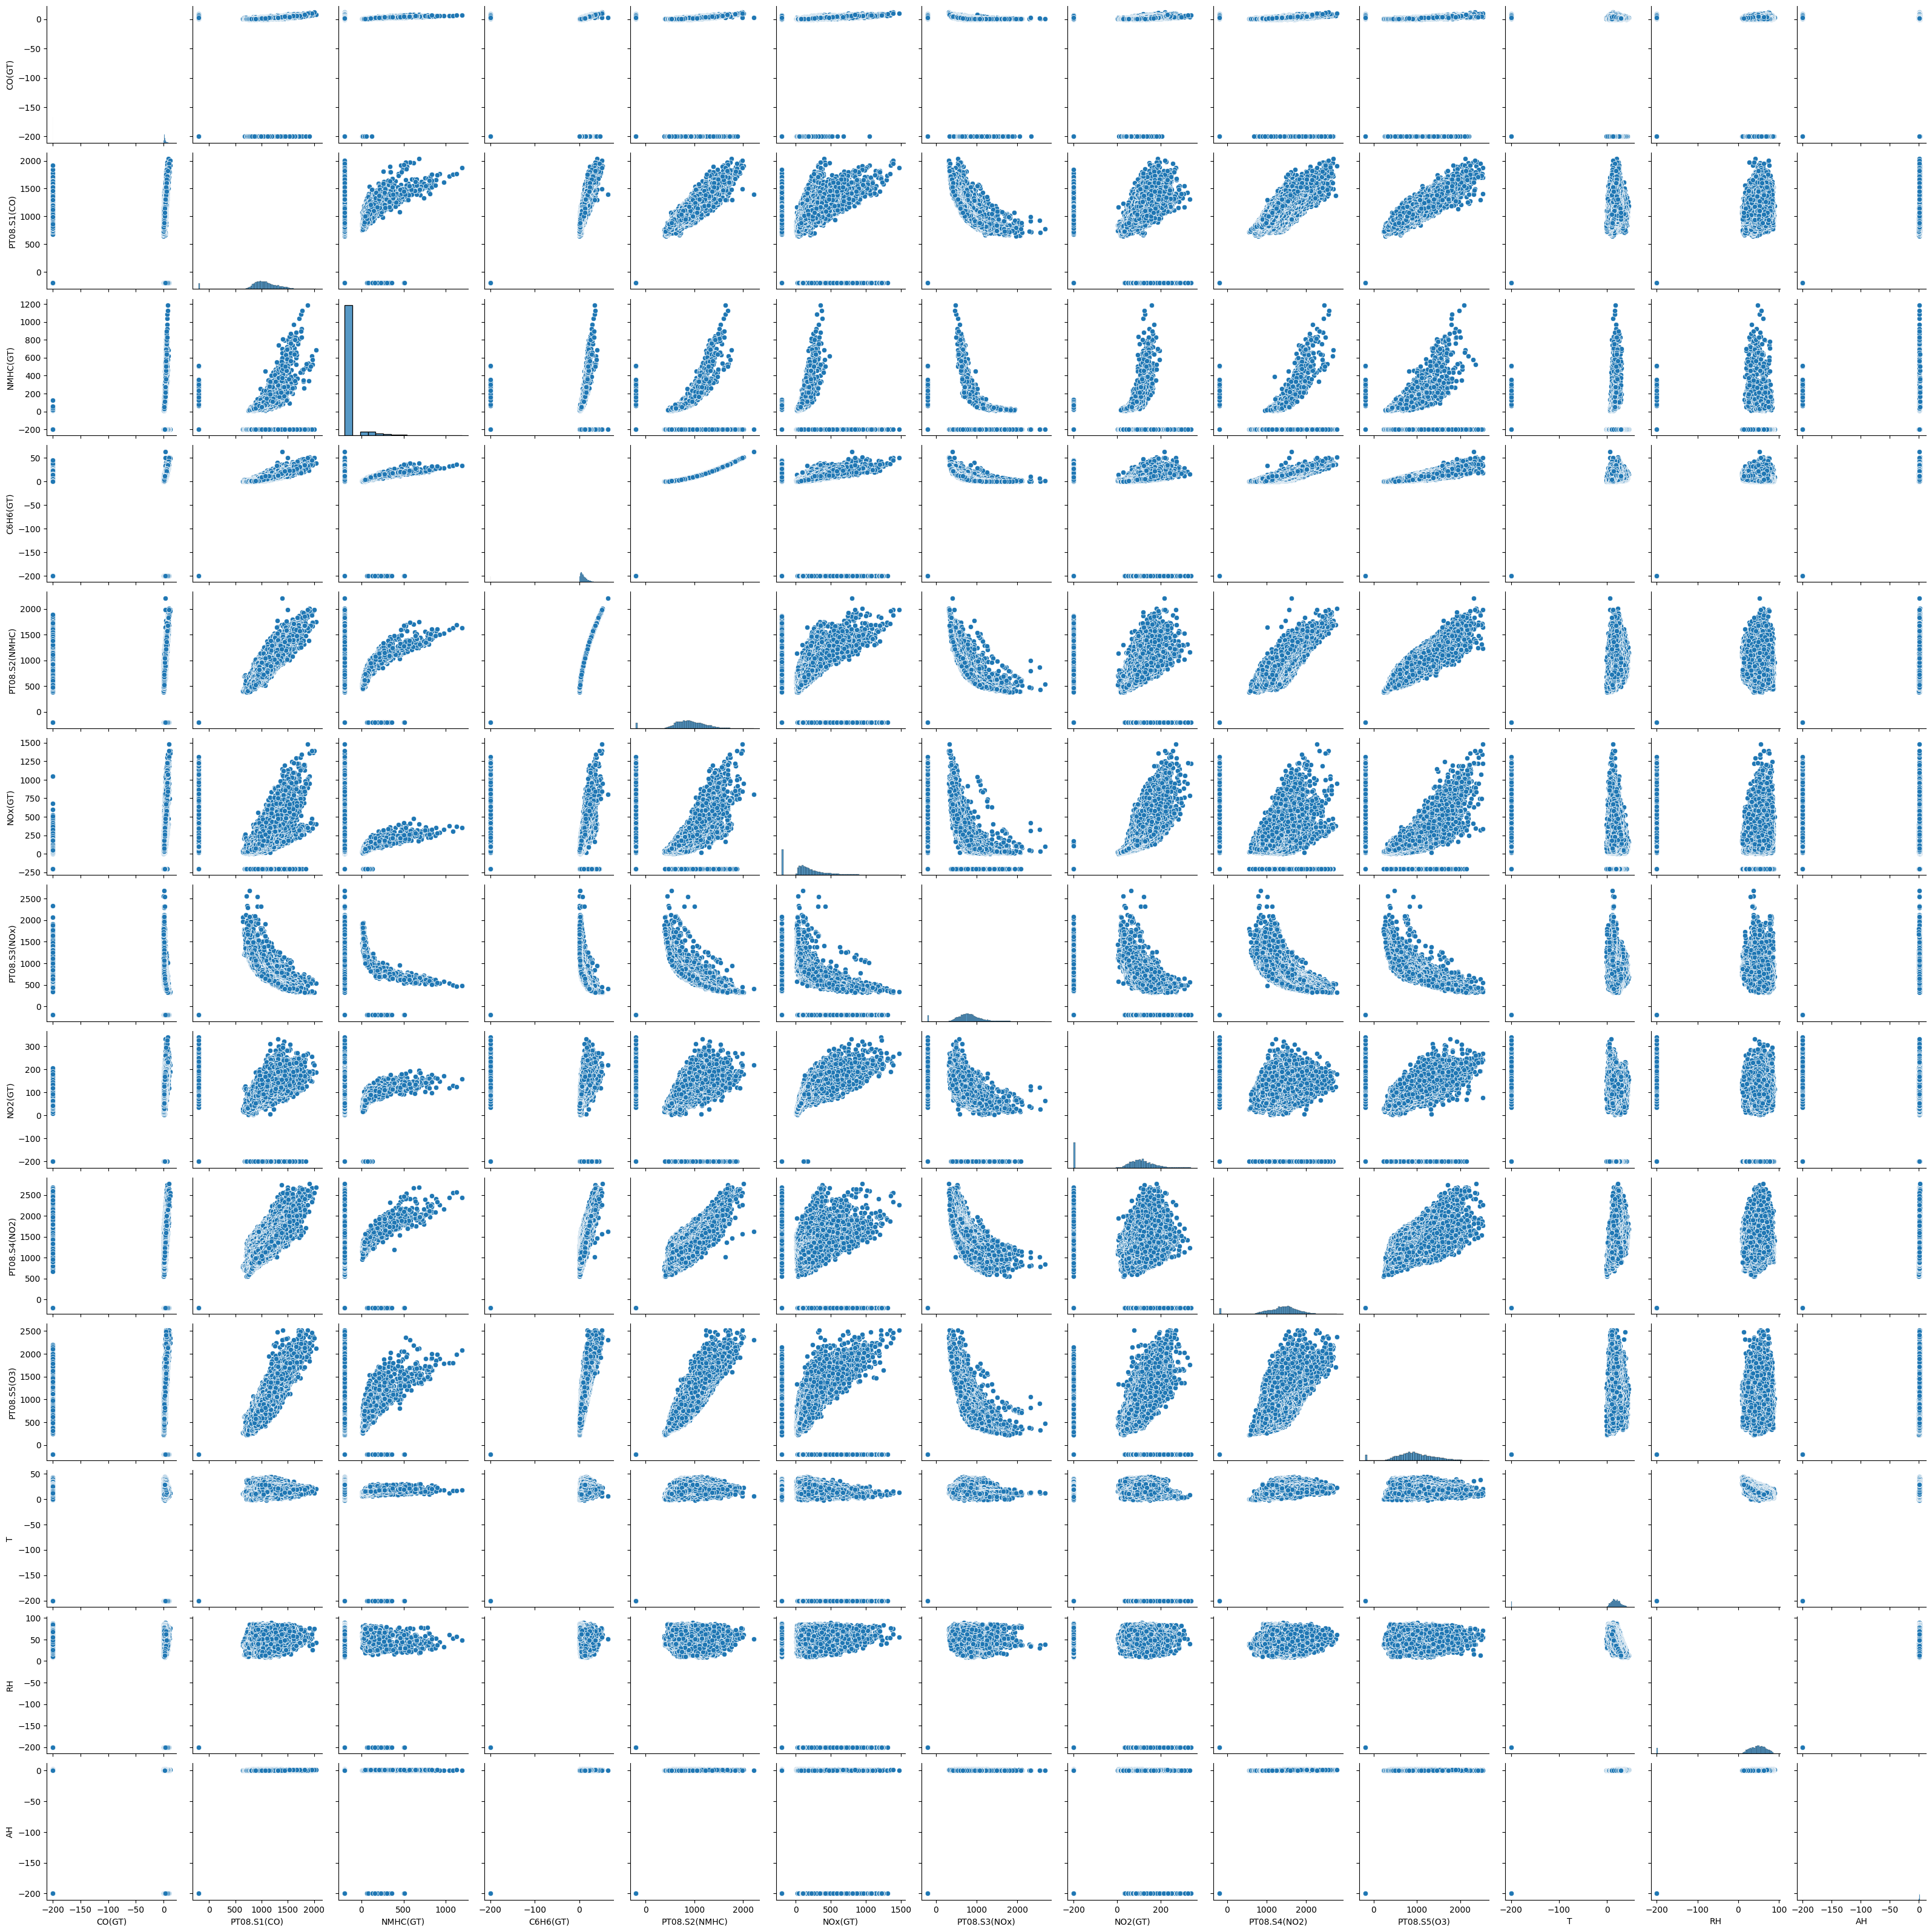

In [290]:
sns.pairplot(df_corr)